# **1. import necessary libraries**

In [5]:
import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

# **2.load dataset**

In [9]:
#uci dataset loading
chronic_kidney_disease = fetch_ucirepo(id=336)

X_uci = chronic_kidney_disease.data.features
y_uci = chronic_kidney_disease.data.targets

# Combine features + target
df_uci = pd.concat([X_uci, y_uci], axis=1)

df_uci.columns = df_uci.columns.str.lower().str.strip()

In [11]:
df_kaggle = pd.read_csv("/content/kidney_disease.csv")

df_kaggle.columns = df_kaggle.columns.str.lower().str.strip()

# **3. starndardize the target column**

In [13]:
df_uci["class"] = df_uci["class"].astype(str).str.lower().str.strip()
df_kaggle["classification"] = df_kaggle["classification"].astype(str).str.lower().str.strip()

label_map = {
    "ckd": 1,
    "notckd": 0,
    "ckd\t": 1,
    "notckd\t": 0
}

df_uci["class"] = df_uci["class"].replace(label_map)
df_kaggle["classification"] = df_kaggle["classification"].replace(label_map)

/tmp/ipython-input-4263526704.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_uci["class"] = df_uci["class"].replace(label_map)
/tmp/ipython-input-4263526704.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_kaggle["classification"] = df_kaggle["classification"].replace(label_map)


# **4. merge the two dataset**

In [14]:
df = pd.concat([df_uci, df_kaggle], ignore_index=True)

In [15]:
df.shape

(800, 29)

# **5. split the feature target column**

In [16]:
X = df.drop(columns=["class"])
y = df["class"]

# **6. encode categorical columns**

In [17]:
cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    X[col] = X[col].astype(str)
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# **6. handle missing values**

In [20]:
df.isnull().sum()


,0
age,18
bp,24
sg,94
al,92
su,98
rbc,304
pc,130
pcc,8
ba,8
bgr,88


In [21]:
#impute for small data
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Remove NaN labels
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

In [22]:
df.isnull().sum()

,0
age,18
bp,24
sg,94
al,92
su,98
rbc,304
pc,130
pcc,8
ba,8
bgr,88


## **7. split the data set**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **9. load the model**

In [25]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **10. train the model[link text](https://)**

In [26]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.7729 - loss: 0.5445 - val_accuracy: 0.9844 - val_loss: 0.3729
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9078 - loss: 0.3671 - val_accuracy: 1.0000 - val_loss: 0.2373
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9845 - loss: 0.2156 - val_accuracy: 1.0000 - val_loss: 0.1495
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9674 - loss: 0.1672 - val_accuracy: 1.0000 - val_loss: 0.0957
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9742 - loss: 0.1095 - val_accuracy: 1.0000 - val_loss: 0.0629
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9789 - loss: 0.0830 - val_accuracy: 1.0000 - val_loss: 0.0425
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9981 - loss: 0.0627 - val_accuracy: 1.0000 - val_loss: 0.0301
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0369 - val_accuracy: 1.0000 - val_loss: 0.0223

In [27]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        30
         1.0       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



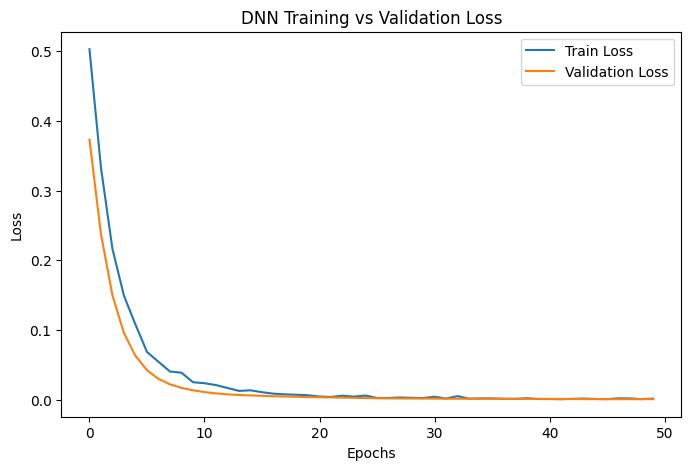

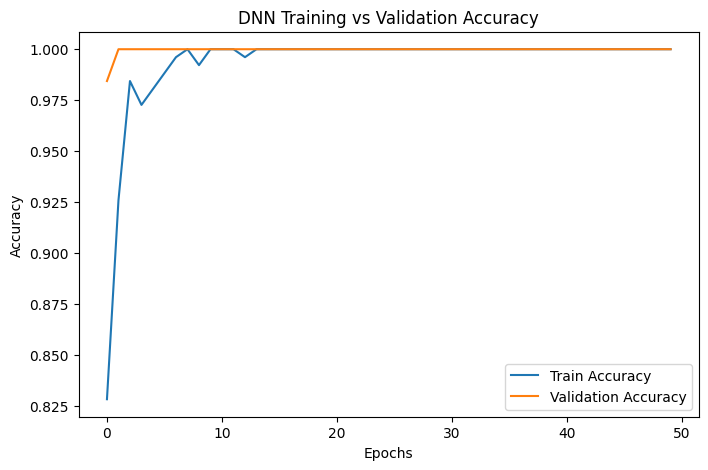

In [29]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("DNN Training vs Validation Loss")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("DNN Training vs Validation Accuracy")
plt.legend()
plt.show()

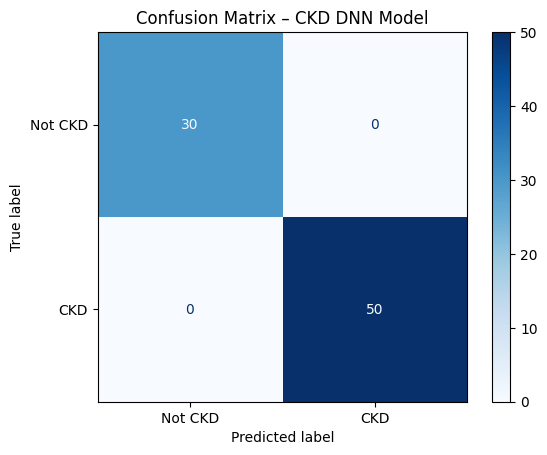

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not CKD", "CKD"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – CKD DNN Model")
plt.show()

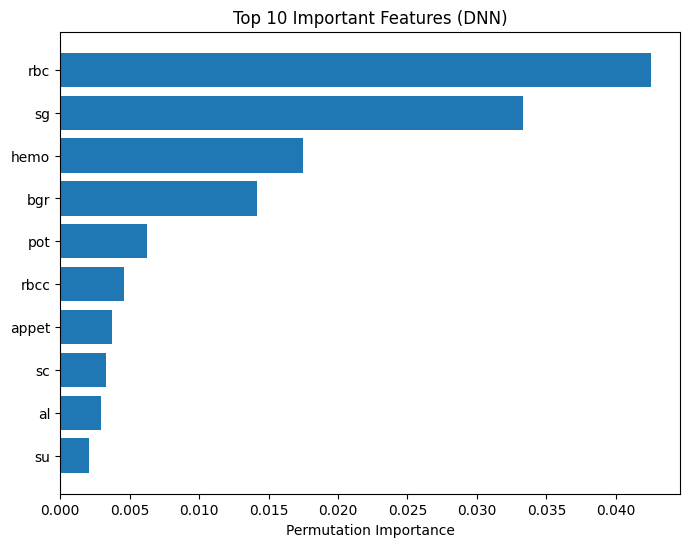

In [38]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

# Define a custom scoring function that permutation_importance can use
def custom_accuracy_scorer(estimator, X, y_true):
    # Keras model.predict returns probabilities, so we need to threshold them
    y_pred_proba = estimator.predict(X, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)
    return accuracy_score(y_true, y_pred)

# Pass this custom function directly as the scoring argument
r = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42, scoring=custom_accuracy_scorer)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': r.importances_mean
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"][:10],
    importance_df["importance"][:10]
)
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance")
plt.title("Top 10 Important Features (DNN)")
plt.show()

PermutationExplainer explainer: 81it [00:25,  3.09it/s]
/tmp/ipython-input-3282952182.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:100], feature_names=X.columns)


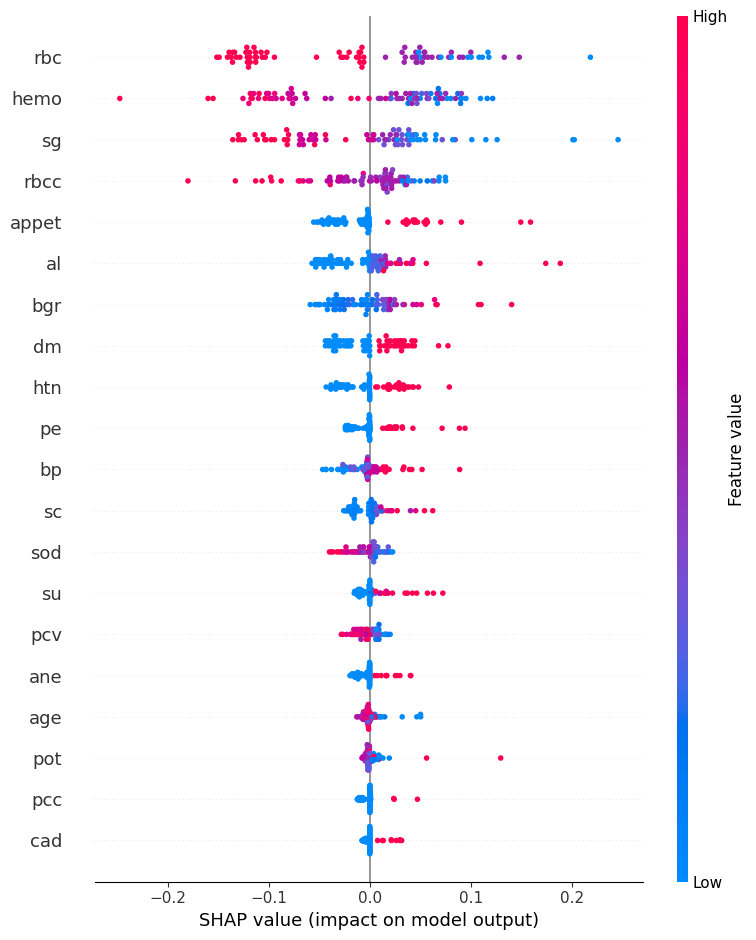

In [39]:
!pip install shap
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test[:100])

shap.summary_plot(shap_values, X_test[:100], feature_names=X.columns)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
6550/6550 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

/tmp/ipython-input-1541717566.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


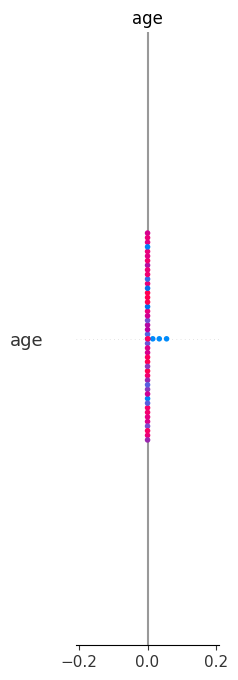

In [41]:
import shap

# Use small background set for speed
background = X_train[:100]

explainer = shap.KernelExplainer(
    model.predict,
    background
)

shap_values = explainer.shap_values(X_test[:50])
shap.summary_plot(
    shap_values,
    X_test[:50],
    feature_names=X.columns
)

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        30
         1.0       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [44]:
import pandas as pd

rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_importance.head(10)

,feature,importance
14,hemo,0.200350
2,sg,0.166882
17,rbcc,0.104159
11,sc,0.097452
3,al,0.086347
5,rbc,0.076168
15,pcv,0.068060
18,htn,0.037930
9,bgr,0.034896
19,dm,0.033203


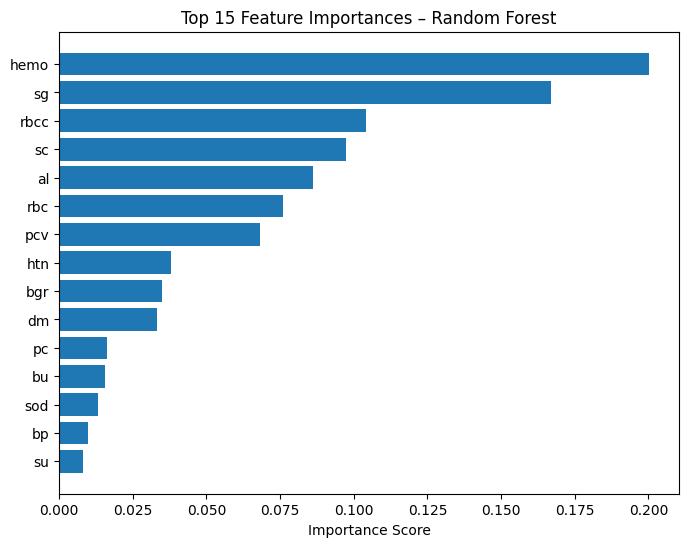

In [45]:
plt.figure(figsize=(8,6))
plt.barh(
    rf_importance["feature"].head(15),
    rf_importance["importance"].head(15)
)
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances – Random Forest")
plt.show()

In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["DNN", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Recall (CKD)": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Recall (CKD),F1 Score
0,DNN,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0


# **model save**

In [28]:
model.save("ckd_dnn_model.keras")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [47]:
import joblib

joblib.dump(rf_model, "ckd_random_forest.pkl")

['ckd_random_forest.pkl']